In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

In [3]:
targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
# drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade', 
#                  'Teeth', 'Yield', 'Animal Type_num', 'Grade_num', 'Presentation Grade_num', 'Waste',
#                  "price/kg", 'Animal Type', 'max_lag']
drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade', 
                 'Teeth', 'Yield', 'Grade_num', 'Presentation Grade_num', 'Waste', 'Age',
                 "price/kg", 'Animal Type', 'max_lag']

In [8]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
df_win = pd.read_csv('data/beef_weather_windows.csv')
data =  beef.join(df_win)

# Top Weather Features per Animal Type

In [9]:
# Identify weather features (our engineered window features)
weather_features = [c for c in data.columns if "__win" in c]

# Static features: everything that's not a target, not a weather feature, not in drop_features
static_features = [
    c for c in data.columns
    if c not in targets
    and c not in drop_features
    and "__win" not in c
]

print("Number of static features:", len(static_features))
print("Number of weather features:", len(weather_features))

Number of static features: 4
Number of weather features: 310


In [10]:
animal_types = ["steer", "heifer", "cow"]
corr_results = {}

for atype in animal_types:
    sub = data[data["Animal Type"].astype(str).str.lower() == atype].copy()
    
    # keep only price + weather, drop rows with missing values
    cols = ["price"] + weather_features
    sub = sub[cols].dropna()
    if sub.empty:
        print(f"No data for {atype}, skipping.")
        continue
    
    # Spearman correlation of each weather feature with price
    corrs = sub[weather_features].corrwith(sub["price"], method="spearman")
    corrs = corrs.dropna()
    
    corr_df = (
        corrs.to_frame("spearman_corr")
             .assign(abs_corr=lambda df: df["spearman_corr"].abs())
             .sort_values("abs_corr", ascending=False)
    )
    corr_results[atype] = corr_df
    
    # print(f"\nTop 10 weather–price correlations for {atype}:")
    # display(corr_df.head(10))


c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


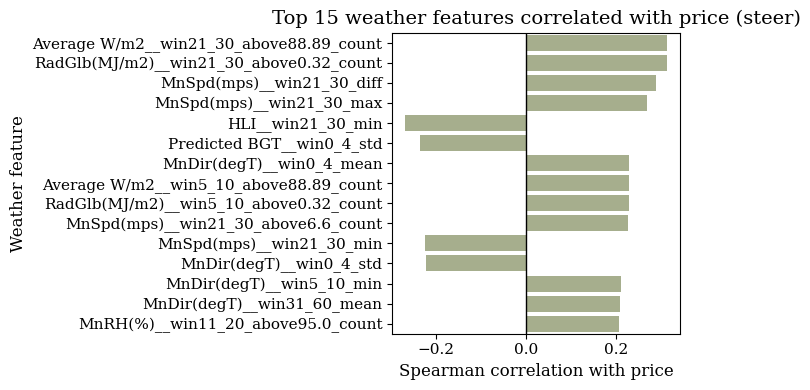

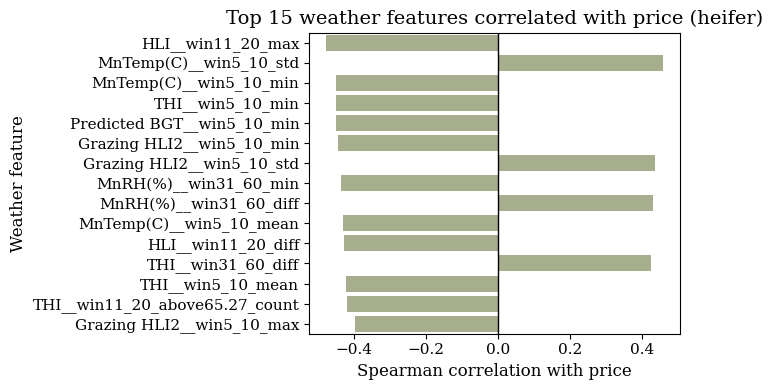

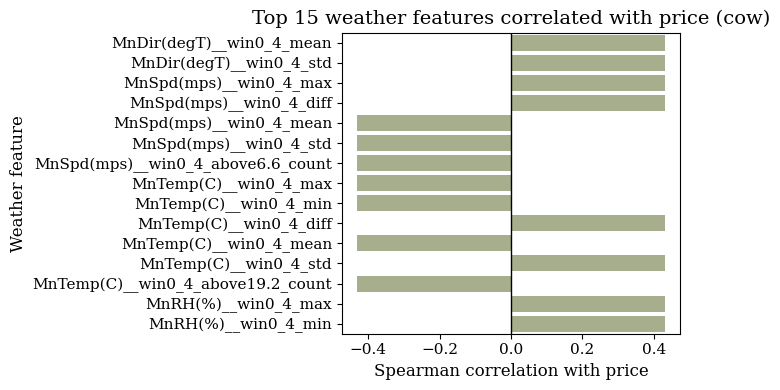

In [11]:
topN = 15

for atype, corr_df in corr_results.items():
    top_corr = corr_df.head(topN).reset_index().rename(columns={"index": "feature"})
    
    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=top_corr,
        x="spearman_corr",
        y="feature",
        color=COLORS[1]
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Top {topN} weather features correlated with price ({atype})")
    plt.xlabel("Spearman correlation with price")
    plt.ylabel("Weather feature")
    plt.tight_layout()
    plt.show()

# Interpretable Models

In [12]:

df = data[data["Animal Type"].str.lower().isin(["steer", "heifer"])].copy()

In [13]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models_interpret = {}

for atype in ["steer", "heifer"]:
    
    # subset and drop rows with missing price
    sub = df[df["Animal Type"].str.lower() == atype].copy()
    sub = sub.dropna(subset=["price"])
    
    # X = weather-only for interpretability
    X = sub[weather_features].copy()
    y = sub["price"].copy()

    # 1) drop weather columns that are mostly NaN (>50%)
    col_na_fraction = X.isna().mean()
    keep_cols = col_na_fraction[col_na_fraction < 0.5].index
    X = X[keep_cols]

    # 2) drop rows with remaining NaNs in X (and sync y)
    row_mask = ~X.isna().any(axis=1)
    X = X[row_mask]
    y = y[row_mask]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            cv=5,
            random_state=42,
            l1_ratio=[0.1, 0.5, 0.9, 1.0],
            max_iter=50000
        ))
    ])

    model.fit(X, y)
    models_interpret[atype] = (model, X.columns)

    coefs = pd.Series(model.named_steps["enet"].coef_, index=X.columns)


In [14]:
def plot_elasticnet_topN(model, feature_names, title="ElasticNet Top Weather Effects", topN=20):
    # extract coefficients
    coefs = pd.Series(model.named_steps["enet"].coef_, index=feature_names)

    # keep only non-zero
    nz = coefs[coefs != 0]

    if len(nz) == 0:
        print("No non-zero coefficients.")
        return
    
    # sort by absolute magnitude and take top N
    nz_top = nz.reindex(nz.abs().sort_values(ascending=False).index[:topN])

    plt.figure(figsize=(10, max(4, len(nz_top) * 0.3)))
    sns.barplot(
        x=nz_top.values,
        y=nz_top.index,
        color=COLORS2[1]
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Coefficient value")
    plt.ylabel("Weather feature")
    plt.tight_layout()
    plt.show()

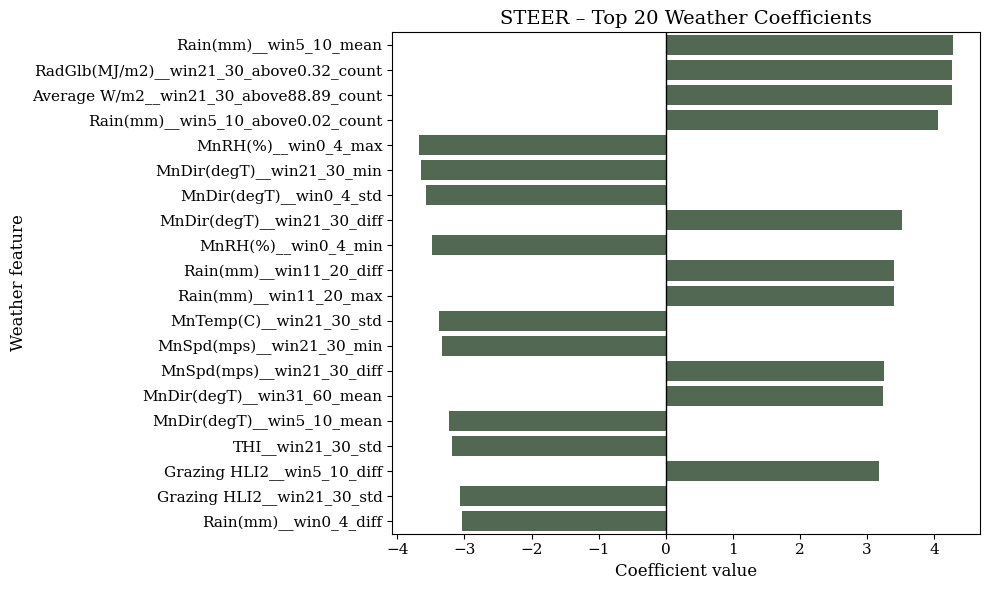

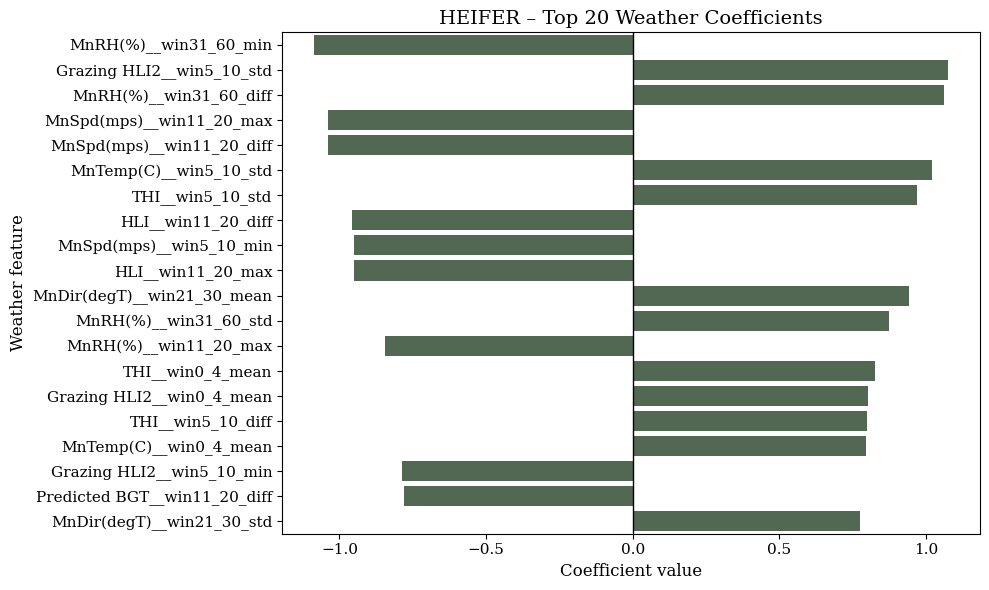

In [15]:
for atype in ["steer", "heifer"]:
    model, cols = models_interpret[atype]
    plot_elasticnet_topN(
        model, 
        cols, 
        title=f"{atype.upper()} – Top 20 Weather Coefficients",
        topN=20
    )

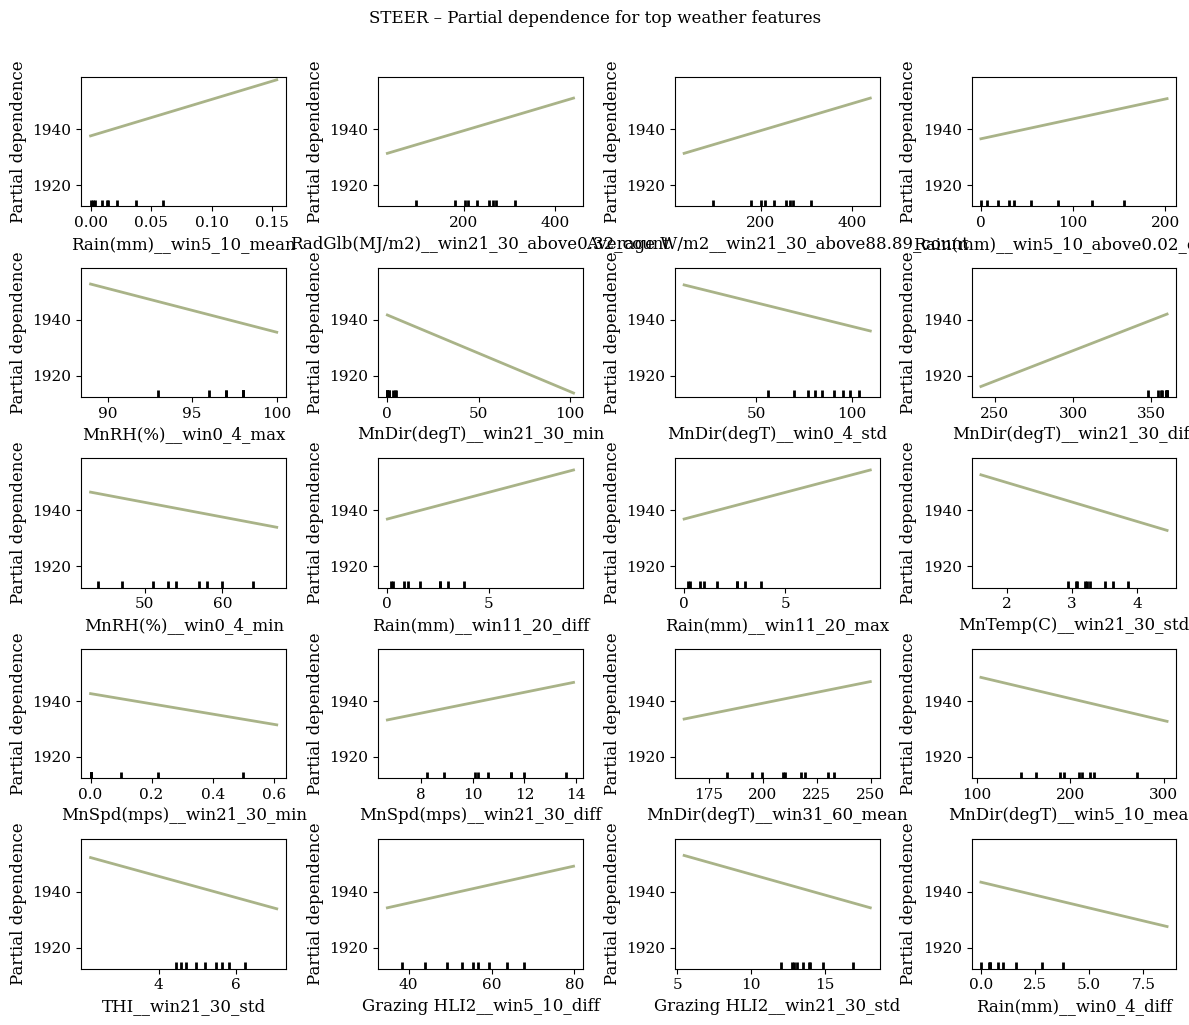

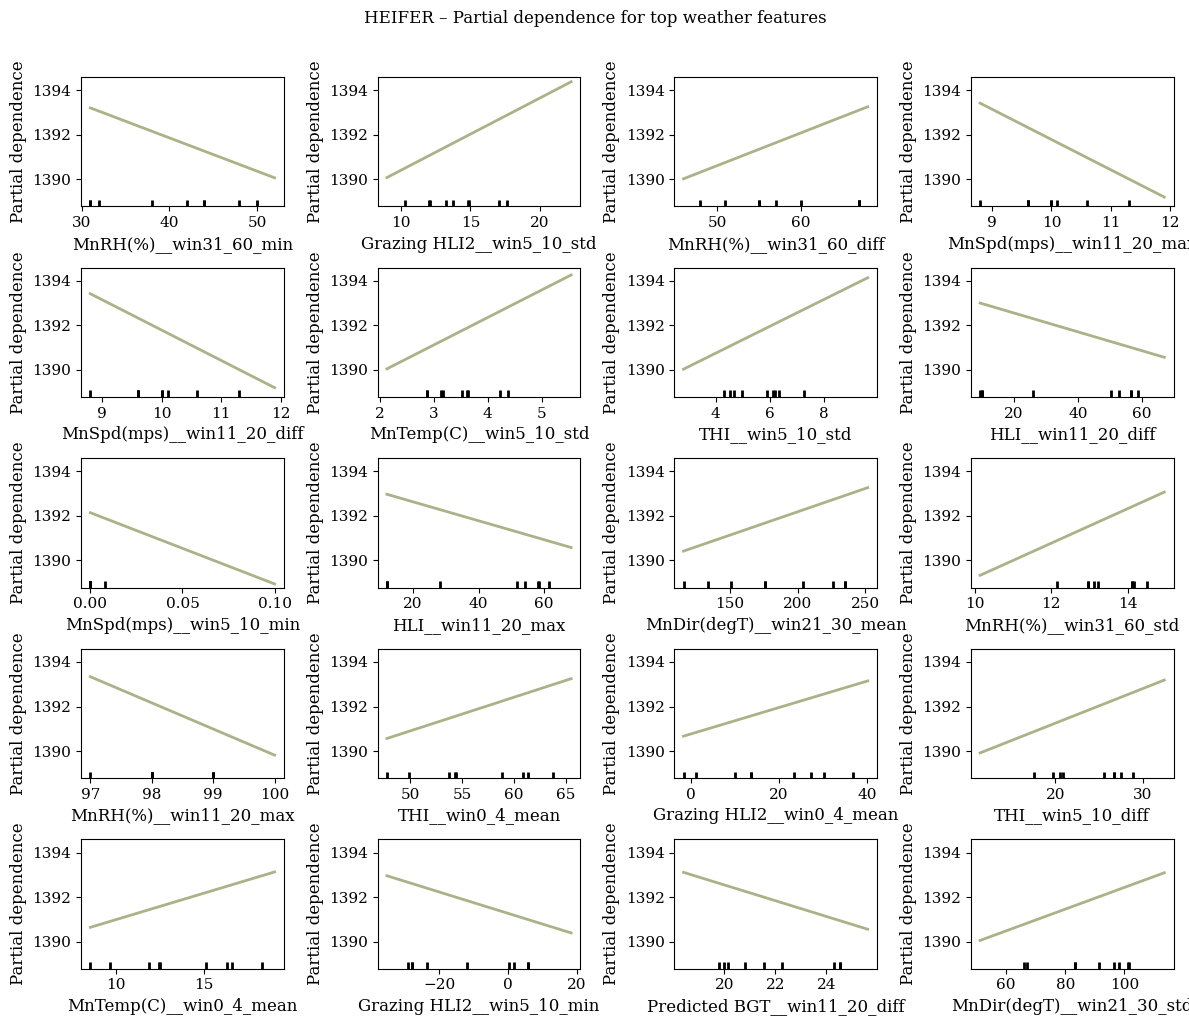

In [16]:
from math import ceil
from sklearn.inspection import PartialDependenceDisplay

TOP_K = 20        # how many top features to plot
MAX_COLS = 4      # wrap after 4 columns

for atype in ["steer", "heifer"]:
    model, feat_names = models_interpret[atype]
    feat_names = list(feat_names)

    # recreate X used for fitting: same subset + same columns, drop NaNs
    sub = df[df["Animal Type"].str.lower() == atype].copy()
    sub = sub.dropna(subset=["price"])
    X = sub[feat_names].copy()
    X = X.dropna(axis=0)

    # get coefficients and select top-K by |coef|
    coefs = pd.Series(model.named_steps["enet"].coef_, index=feat_names)
    nz = coefs[coefs != 0]
    if nz.empty:
        print(f"{atype.upper()}: all coefficients are zero, skipping PDP.")
        continue

    top_features = nz.abs().sort_values(ascending=False).head(TOP_K).index.tolist()
    n_feat = len(top_features)

    ncols = min(MAX_COLS, n_feat)
    nrows = ceil(n_feat / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3 * ncols, 2 * nrows),
        squeeze=False,
    )

    # flatten axes to 1D list for sklearn
    ax_flat = axes.ravel()

    # make PDPs
    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=top_features,
        kind="average",
        grid_resolution=50,
        ax=ax_flat[:n_feat],   # only as many axes as features
        line_kw={"color": COLORS[1]}
    )

    # hide any unused subplots
    for extra_ax in ax_flat[n_feat:]:
        extra_ax.set_visible(False)

    fig.suptitle(f"{atype.upper()} – Partial dependence for top weather features", y=1.02)
    plt.tight_layout()
    plt.show()


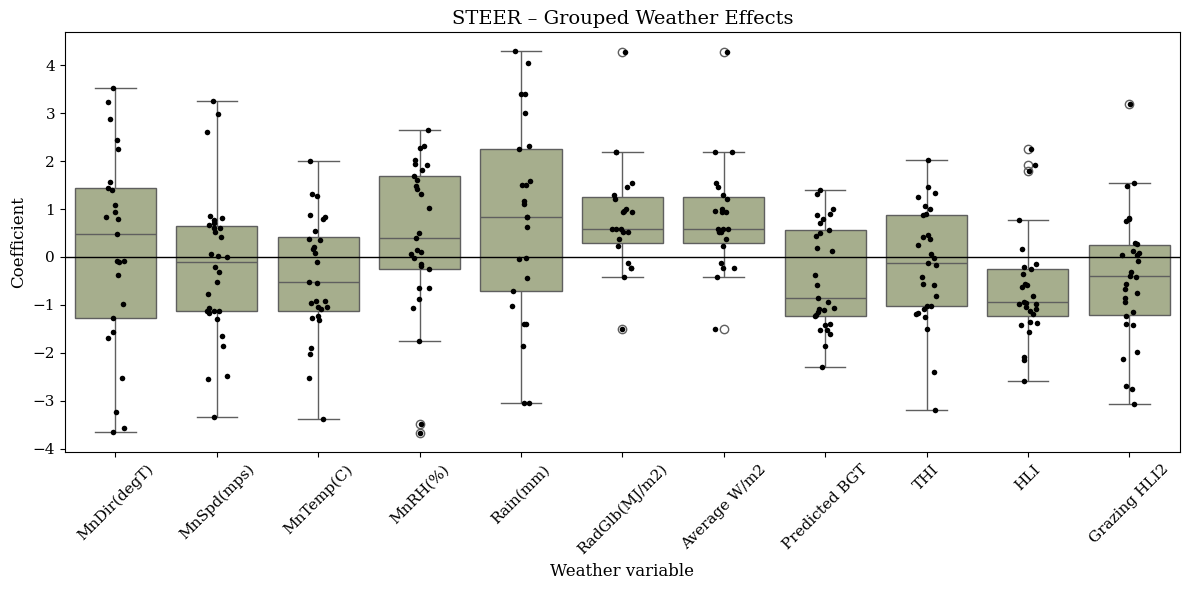

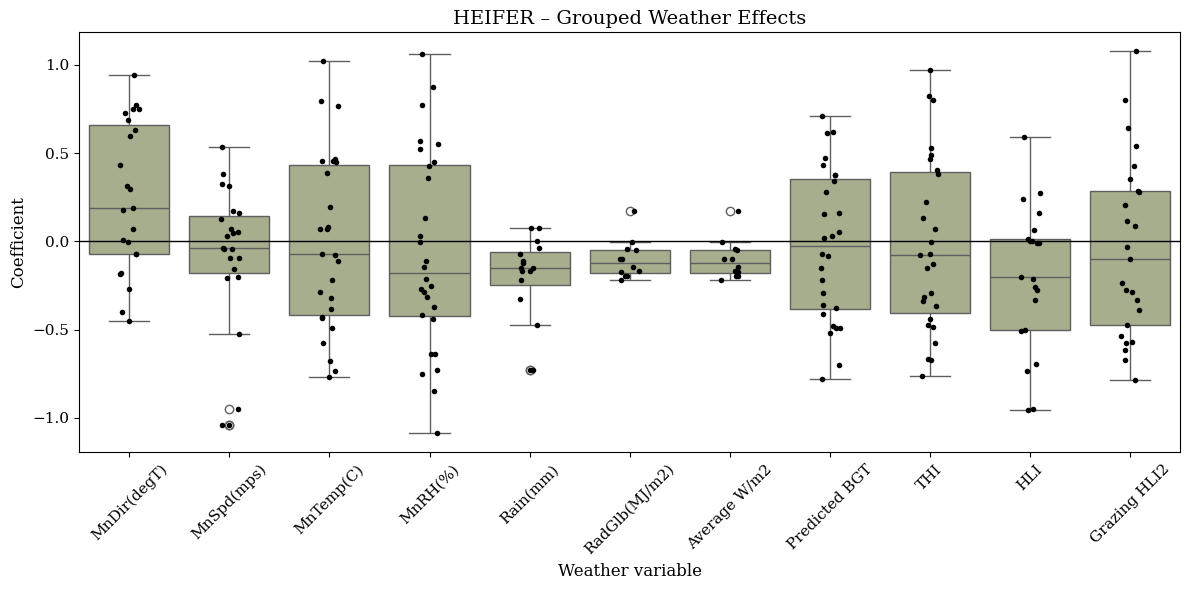

In [17]:
def plot_grouped_coefs(model, feature_names, title):
    coefs = pd.Series(model.named_steps["enet"].coef_, index=feature_names)
    nz = coefs[coefs != 0]

    df = (
        nz.reset_index()
          .rename(columns={"index": "feature", 0: "coef"})
    )
    df["variable"] = df["feature"].apply(lambda x: x.split("__")[0])
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="variable", y="coef", color=COLORS[1])
    sns.stripplot(data=df, x="variable", y="coef", color="black", s=4, jitter=True)

    plt.axhline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Weather variable")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for atype in ["steer", "heifer"]:
    model, cols = models_interpret[atype]
    plot_grouped_coefs(model, cols, f"{atype.upper()} – Grouped Weather Effects")


# Understanding Weather Impacts

In [18]:
# start from your joined table: `data`
df = data[data["Animal Type"].str.lower().isin(["steer", "heifer"])].copy()

In [19]:
# prefixes we consider "heat stress" indicators
heat_prefixes = [
    "THI__",
    "HLI__",
    "Grazing HLI2__",
    "Predicted BGT__",
    "MnTemp(C)__",
]

# select exposure/count features for these indicators
exposure_cols = [
    c for c in df.columns
    if "_count" in c and any(c.startswith(p) for p in heat_prefixes)
]

In [20]:
import statsmodels.api as sm

def run_exposure_regressions(df, exposure_cols, min_n=30):
    results = []

    for atype in ["steer", "heifer"]:
        sub = df[df["Animal Type"].str.lower() == atype].copy()
        sub = sub.dropna(subset=["price"])

        for col in exposure_cols:
            if col not in sub.columns:
                continue

            sub_col = sub[["price", col]].dropna()
            n = len(sub_col)
            if n < min_n:
                continue  # too few observations for this window/feature

            X = sm.add_constant(sub_col[[col]])
            y = sub_col["price"]

            model = sm.OLS(y, X).fit()

            slope = model.params[col]
            pval = model.pvalues[col]
            r2   = model.rsquared

            results.append({
                "animal_type": atype,
                "feature": col,
                "n": n,
                "slope": slope,
                "p_value": pval,
                "R2": r2,
            })

    return pd.DataFrame(results)


exposure_results = run_exposure_regressions(df, exposure_cols, min_n=30)
exposure_results.head()


,animal_type,feature,n,slope,p_value,R2
0,steer,MnTemp(C)__win0_4_above19.2_count,626,-0.047848,0.405231,0.001110
1,steer,Predicted BGT__win0_4_above22.94_count,626,0.193077,0.024140,0.008122
2,steer,THI__win0_4_above65.27_count,626,-0.037030,0.452434,0.000905
3,steer,HLI__win0_4_above11.46_count,626,-0.173557,0.058170,0.005739
4,steer,Grazing HLI2__win0_4_above40.41_count,626,-0.161832,0.002013,0.015181


In [21]:
# sort by strongest *harmful* effects
harmful = (
    exposure_results
    .sort_values("slope")         # most negative first
    .reset_index(drop=True)
)

print("Top 15 harmful heat exposures (more → lower price):")
display(harmful.head(15))


# sort by strongest *beneficial* effects
beneficial = (
    exposure_results
    .sort_values("slope", ascending=False)   # most positive first
    .reset_index(drop=True)
)

print("Top 15 beneficial heat exposures (more → higher price):")
display(beneficial.head(15))


Top 15 harmful heat exposures (more → lower price):


,animal_type,feature,n,slope,p_value,R2
0,heifer,MnTemp(C)__win5_10_above19.2_count,233,-0.317917,0.000083,0.065012
1,heifer,Predicted BGT__win5_10_above22.94_count,233,-0.315811,0.000133,0.061373
2,heifer,THI__win5_10_above65.27_count,233,-0.313808,0.000073,0.066019
3,heifer,Grazing HLI2__win5_10_above40.41_count,233,-0.309795,0.000041,0.070418
4,heifer,HLI__win5_10_above11.46_count,233,-0.191262,0.123069,0.010263
5,heifer,HLI__win0_4_above11.46_count,233,-0.187844,0.044830,0.017311
6,steer,HLI__win0_4_above11.46_count,626,-0.173557,0.058170,0.005739
7,steer,Grazing HLI2__win0_4_above40.41_count,626,-0.161832,0.002013,0.015181
8,heifer,Predicted BGT__win11_20_above22.94_count,219,-0.136020,0.004666,0.036297
9,heifer,HLI__win11_20_above11.46_count,219,-0.118402,0.039724,0.019347


Top 15 beneficial heat exposures (more → higher price):


,animal_type,feature,n,slope,p_value,R2
0,steer,Predicted BGT__win0_4_above22.94_count,626,0.193077,0.024140,0.008122
1,steer,Predicted BGT__win5_10_above22.94_count,626,0.134317,0.038226,0.006865
2,heifer,THI__win0_4_above65.27_count,233,0.053606,0.448076,0.002494
3,heifer,Grazing HLI2__win0_4_above40.41_count,233,0.040838,0.555578,0.001506
4,heifer,MnTemp(C)__win0_4_above19.2_count,233,0.034312,0.648400,0.000902
5,steer,THI__win11_20_above65.27_count,612,0.027832,0.407223,0.001126
6,steer,HLI__win11_20_above11.46_count,612,0.026403,0.566054,0.000540
7,heifer,Predicted BGT__win0_4_above22.94_count,233,0.021940,0.784615,0.000324
8,heifer,Predicted BGT__win31_60_above22.94_count,215,0.016908,0.372664,0.003733
9,steer,Grazing HLI2__win5_10_above40.41_count,626,0.014904,0.762166,0.000147


In [60]:
# Focus on statistically significant results (p < 0.05)
alpha = 0.05  # significance threshold

sig_harmful = harmful[harmful["p_value"] < alpha]
sig_beneficial = beneficial[beneficial["p_value"] < alpha]

print("Significant harmful exposures:")
display(sig_harmful.head(20))

print("Significant beneficial exposures:")
display(sig_beneficial.head(20))


Significant harmful exposures:


,animal_type,feature,n,slope,p_value,R2
0,steer,Grazing HLI2__win15_30_above70_count,585,-6.321490,2.369476e-05,0.030207
1,steer,THI__win15_30_above72_count,585,-1.357949,2.254163e-03,0.015890
2,steer,Grazing HLI2__win31_60_above70_count,617,-1.221045,7.241414e-06,0.032225
4,steer,Grazing HLI2__win4_7_above70_count,626,-0.996555,1.614293e-04,0.022570
5,steer,Grazing HLI2__win8_14_above70_count,612,-0.771430,2.447523e-03,0.014948
6,steer,MnTemp(C)__win15_30_above24_count,585,-0.643844,6.536250e-05,0.026995
7,steer,MnTemp(C)__win0_3_above24_count,626,-0.590091,2.816434e-02,0.007698
8,steer,THI__win0_3_above72_count,626,-0.525092,2.042428e-02,0.008584
9,steer,MnTemp(C)__win31_60_above24_count,617,-0.501087,2.222045e-08,0.049645
10,steer,THI__win31_60_above72_count,617,-0.478372,1.885294e-06,0.036280


Significant beneficial exposures:


,animal_type,feature,n,slope,p_value,R2
18,heifer,Predicted BGT__win15_30_above24_count,219,-0.083037,2.002089e-02,0.024679
20,steer,Predicted BGT__win31_60_above24_count,617,-0.088665,1.134147e-06,0.037811
26,heifer,Predicted BGT__win8_14_above24_count,203,-0.351689,9.773861e-05,0.072914
27,steer,THI__win4_7_above72_count,626,-0.421448,8.308544e-03,0.011110
28,steer,MnTemp(C)__win4_7_above24_count,626,-0.439067,6.781997e-03,0.011687
29,steer,THI__win31_60_above72_count,617,-0.478372,1.885294e-06,0.036280
30,steer,MnTemp(C)__win31_60_above24_count,617,-0.501087,2.222045e-08,0.049645
31,steer,THI__win0_3_above72_count,626,-0.525092,2.042428e-02,0.008584
32,steer,MnTemp(C)__win0_3_above24_count,626,-0.590091,2.816434e-02,0.007698
33,steer,MnTemp(C)__win15_30_above24_count,585,-0.643844,6.536250e-05,0.026995


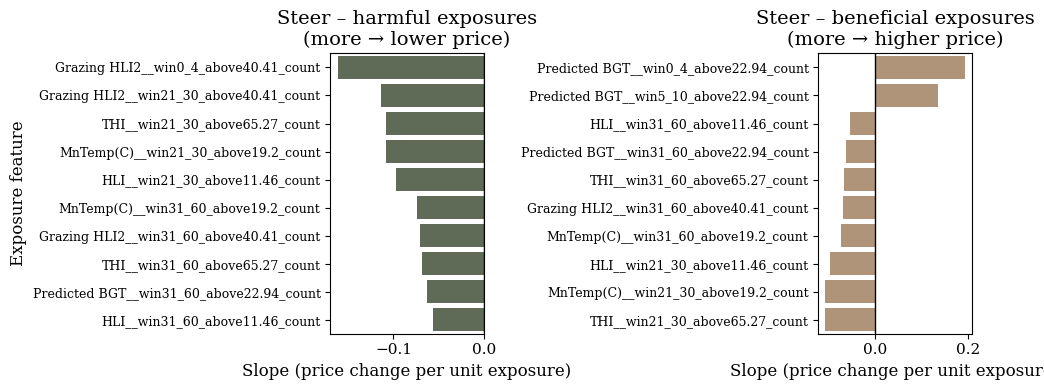

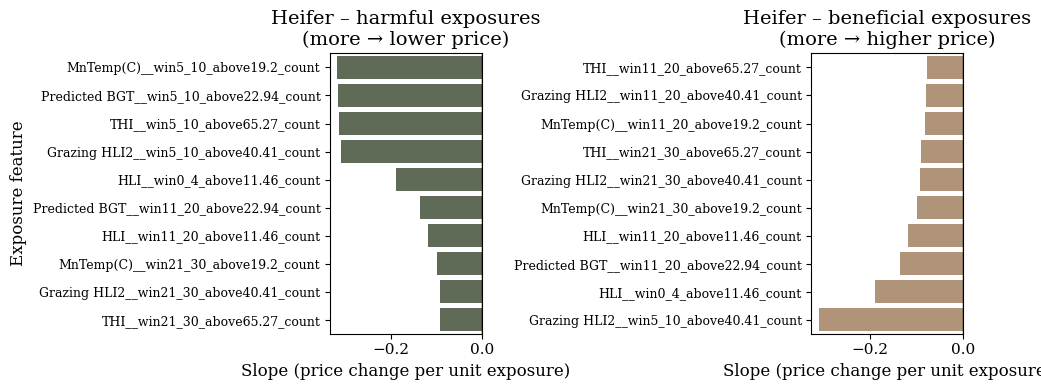

In [22]:
import numpy as np

def plot_exposure_bars(exposure_results, animal_type, topN=10, alpha=0.05):
    sub = exposure_results[exposure_results["animal_type"] == animal_type].copy()
    if sub.empty:
        print(f"No results for {animal_type}")
        return
    
    # mark significance
    sub["neg_log10_p"] = -np.log10(sub["p_value"])
    sig = sub[sub["p_value"] < alpha]
    if sig.empty:
        print(f"No significant exposures for {animal_type} at alpha={alpha}")
    
    # strongest harmful (most negative slopes)
    harmful = sig.sort_values("slope").head(topN)
    # strongest beneficial (most positive slopes)
    beneficial = sig.sort_values("slope", ascending=False).head(topN)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

    # harmful
    sns.barplot(
        data=harmful,
        x="slope",
        y="feature",
        color=COLORS[0],
        ax=axes[0]
    )
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title(f"{animal_type.capitalize()} – harmful exposures\n(more → lower price)")
    axes[0].set_xlabel("Slope (price change per unit exposure)")
    axes[0].set_ylabel("Exposure feature")
    
    # beneficial
    sns.barplot(
        data=beneficial,
        x="slope",
        y="feature",
        color=COLORS[2],
        ax=axes[1]
    )
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title(f"{animal_type.capitalize()} – beneficial exposures\n(more → higher price)")
    axes[1].set_xlabel("Slope (price change per unit exposure)")
    axes[1].set_ylabel("")

    # rotate labels a bit
    axes[0].tick_params(axis="y", labelsize=9)
    axes[1].tick_params(axis="y", labelsize=9)

    plt.tight_layout()
    plt.show()

# call for both animal types
for atype in ["steer", "heifer"]:
    plot_exposure_bars(exposure_results, atype, topN=10, alpha=0.05)


In [66]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# work on steers + heifers only
df = data[data["Animal Type"].str.lower().isin(["steer", "heifer"])].copy()

age_col = "Age"
dist_col = "Transport distance (calculated)"

# heat exposure features: counts above thresholds
exposure_cols = [c for c in df.columns if c.endswith("_count")]

models_weather = {}   # store (model, columns) per animal type

for atype in ["steer", "heifer"]:
    print(f"\n=== {atype.upper()} ===")
    sub = df[df["Animal Type"].str.lower() == atype].copy()

    # features: exposures + confounders
    use_cols = [c for c in exposure_cols if c in sub.columns] + [age_col, dist_col]

    sub = sub.dropna(subset=use_cols + ["price"])
    if sub.empty:
        print("No usable rows after dropping NaNs, skipping.")
        continue

    X = sub[use_cols]
    y = sub["price"]

    print("X shape:", X.shape)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            cv=5,
            random_state=42,
            l1_ratio=[0.1, 0.5, 0.9, 1.0],
            max_iter=50000,
        ))
    ])

    model.fit(X, y)
    models_weather[atype] = (model, use_cols)

    coefs = pd.Series(model.named_steps["enet"].coef_, index=use_cols)
    print("Non-zero coefficients:", (coefs != 0).sum())



=== STEER ===
X shape: (534, 35)
Non-zero coefficients: 34

=== HEIFER ===
X shape: (100, 35)
Non-zero coefficients: 15


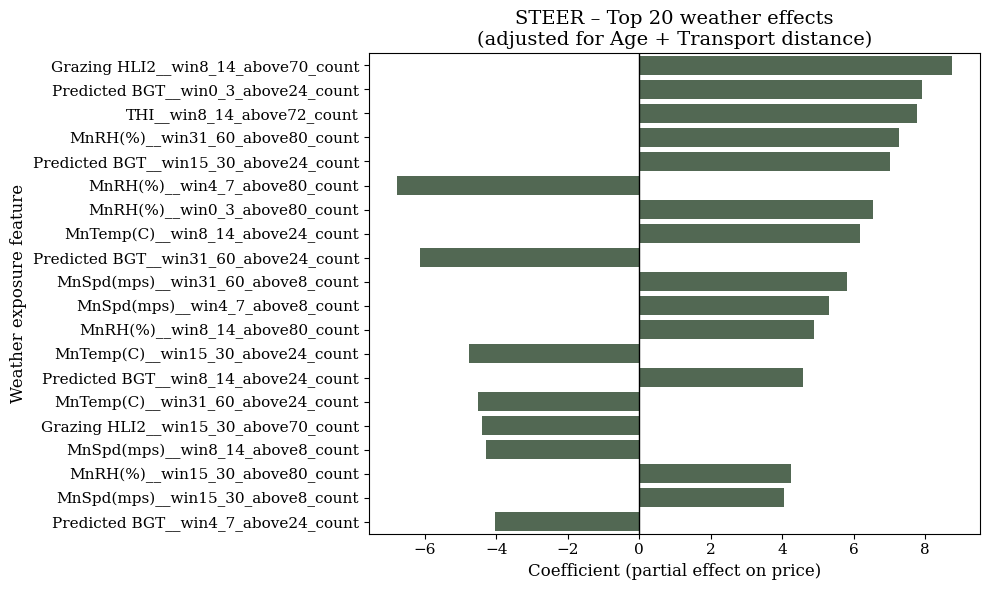

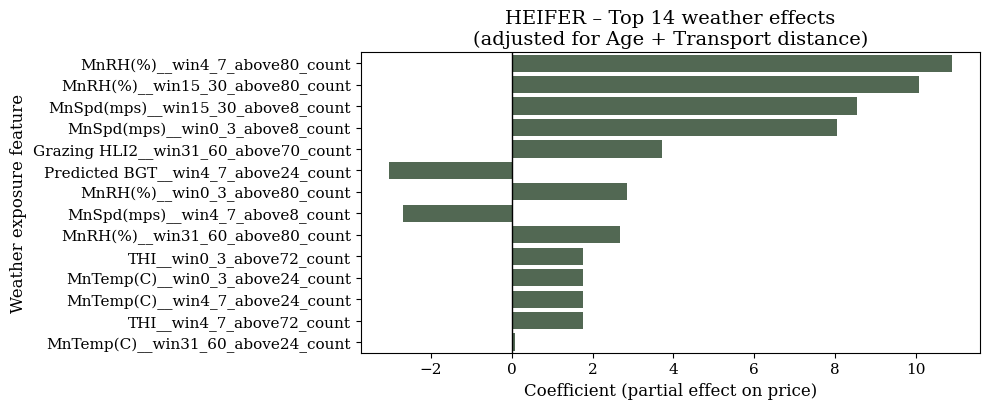

In [67]:
def plot_top_weather_coefs(models_weather, exposure_cols_global, topN=20):
    for atype, (model, cols) in models_weather.items():
        coefs = pd.Series(model.named_steps["enet"].coef_, index=cols)

        # keep only exposure coefficients (exclude Age + distance)
        exp_cols = [c for c in cols if c in exposure_cols_global]
        exp_coefs = coefs[exp_cols]

        # non-zero only
        nz = exp_coefs[exp_coefs != 0]
        if nz.empty:
            print(f"{atype.upper()}: no non-zero weather coefficients.")
            continue

        # top N by |coef|
        nz_top = nz.reindex(nz.abs().sort_values(ascending=False).index[:topN])

        plt.figure(figsize=(10, max(4, len(nz_top) * 0.3)))
        sns.barplot(
            x=nz_top.values,
            y=nz_top.index,
            color=COLORS2[1],
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"{atype.upper()} – Top {len(nz_top)} weather effects\n(adjusted for Age + Transport distance)")
        plt.xlabel("Coefficient (partial effect on price)")
        plt.ylabel("Weather exposure feature")
        plt.tight_layout()
        plt.show()

# call it
plot_top_weather_coefs(models_weather, exposure_cols, topN=20)


### Setup/Helpers

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from lightgbm import LGBMRegressor
from statsmodels.nonparametric.smoothers_lowess import lowess

RANDOM_STATE = 42

# keep only steer + heifer
df_all = data[data["Animal Type"].str.lower().isin(["steer", "heifer"])].copy()

# identify weather features (all windows, incl. counts)
weather_features = [c for c in df_all.columns if "__win" in c]

# drop zero-variance weather cols
w_var = df_all[weather_features].var(numeric_only=True)
weather_features = [c for c in weather_features if w_var.get(c, 0) > 0]

print("Number of weather features:", len(weather_features))


Number of weather features: 310


# 1. ElasticNet to identify important weather features + scatter with nonlinear trend

### 1.1 Fit ElasticNet per target & animal type (weather only)

In [25]:
from collections import defaultdict

# store selected weather features: (target, atype) -> list of feature names
selected_weather = defaultdict(list)

for target in targets:  # ['live weight', 'carcass weight', 'price', 'Total number of defects']
    for atype in ["steer", "heifer"]:
        sub = df_all[df_all["Animal Type"].str.lower() == atype].copy()

        cols = weather_features + [target]
        sub = sub[cols].dropna()

        X = sub[weather_features].copy()
        y = sub[target].copy()

        # drop remaining NaNs row-wise
        mask = ~X.isna().any(axis=1)
        X, y = X[mask], y[mask]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("enet", ElasticNetCV(
                cv=5,
                random_state=RANDOM_STATE,
                l1_ratio=[0.1, 0.5, 0.9, 1.0],
                max_iter=50000
            ))
        ])

        model.fit(X, y)

        coefs = pd.Series(model.named_steps["enet"].coef_, index=X.columns)
        nz = coefs[coefs != 0]

        if nz.empty:
            print(f"No non-zero weather coefs for {atype} / {target}.")
            continue

        # take top K by |coef|
        K = 20
        top = nz.reindex(nz.abs().sort_values(ascending=False).index[:K])
        selected_weather[(target, atype)] = top.index.tolist()

        print(f"{atype.upper()} / {target}: selected {len(top)} weather features.")


STEER / live weight: selected 20 weather features.
HEIFER / live weight: selected 20 weather features.
No non-zero weather coefs for steer / carcass weight.
HEIFER / carcass weight: selected 20 weather features.
STEER / price: selected 20 weather features.
HEIFER / price: selected 20 weather features.
STEER / Total number of defects: selected 9 weather features.
HEIFER / Total number of defects: selected 14 weather features.


### 1.2 Scatter + nonlinear trend (LOWESS) for selected features

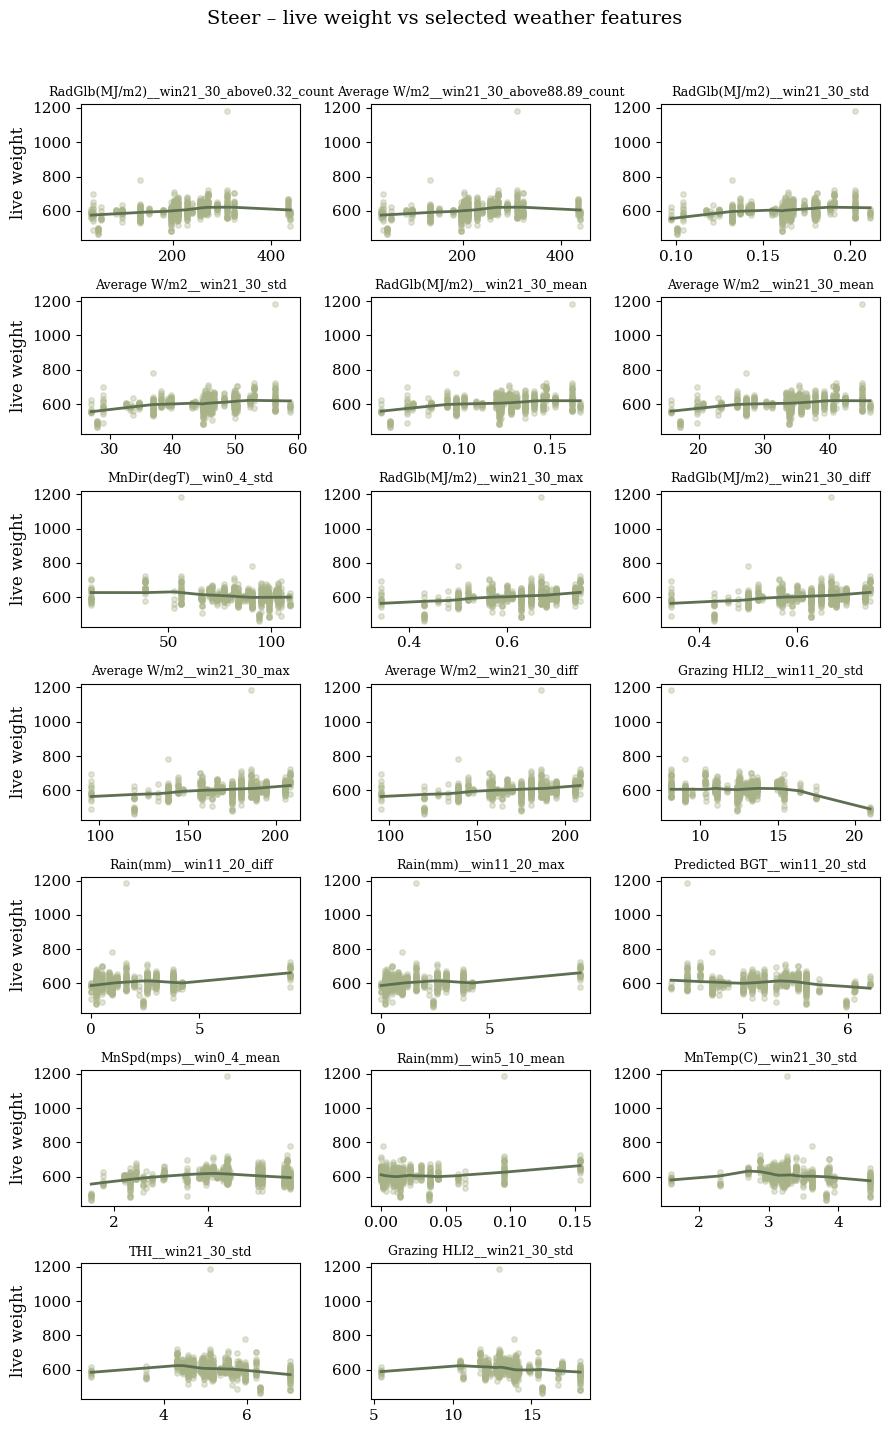

c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


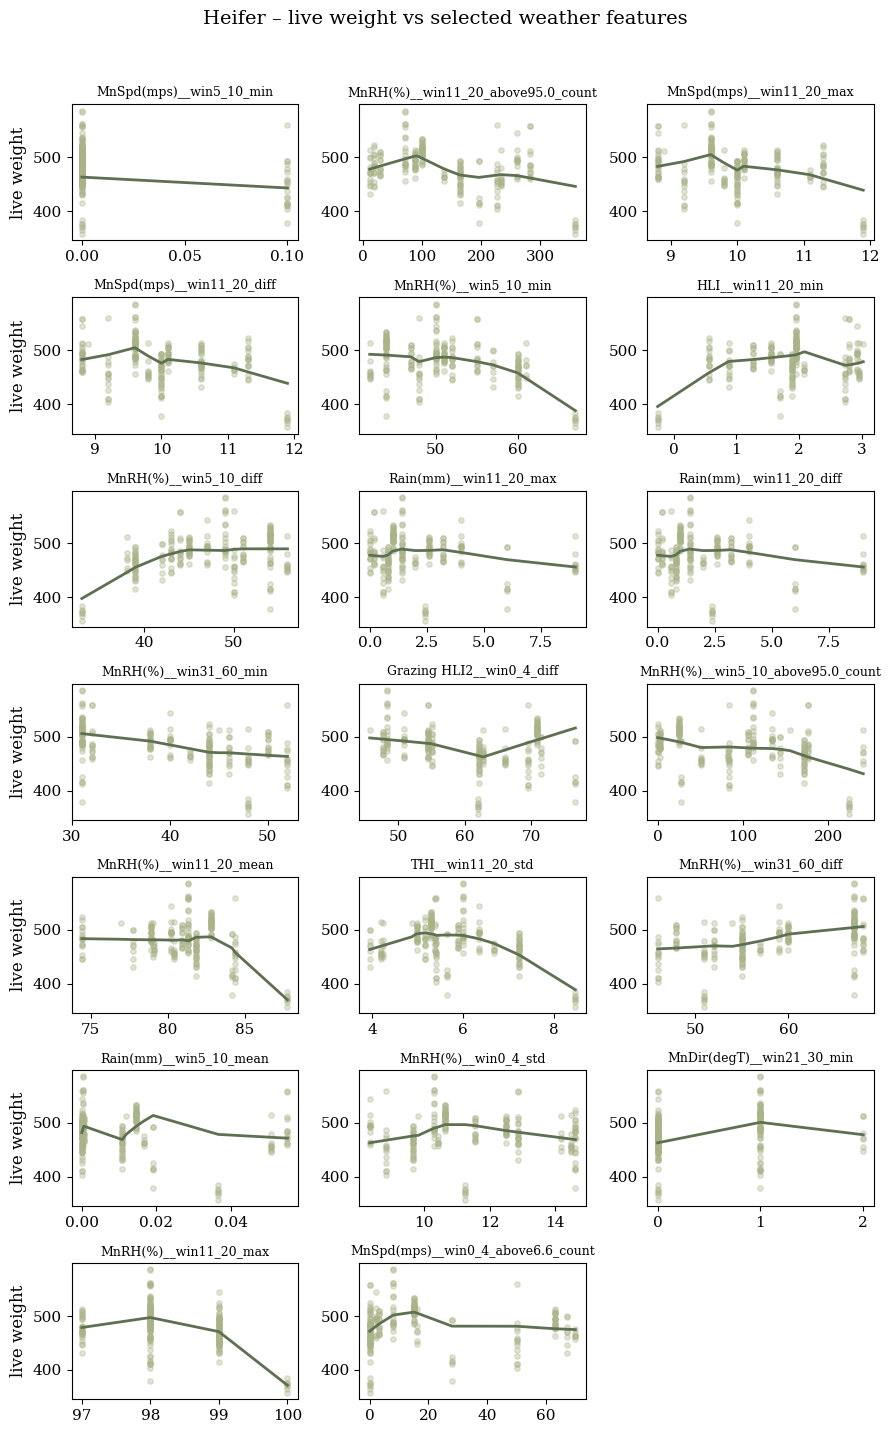

No selected weather features for steer / carcass weight


c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


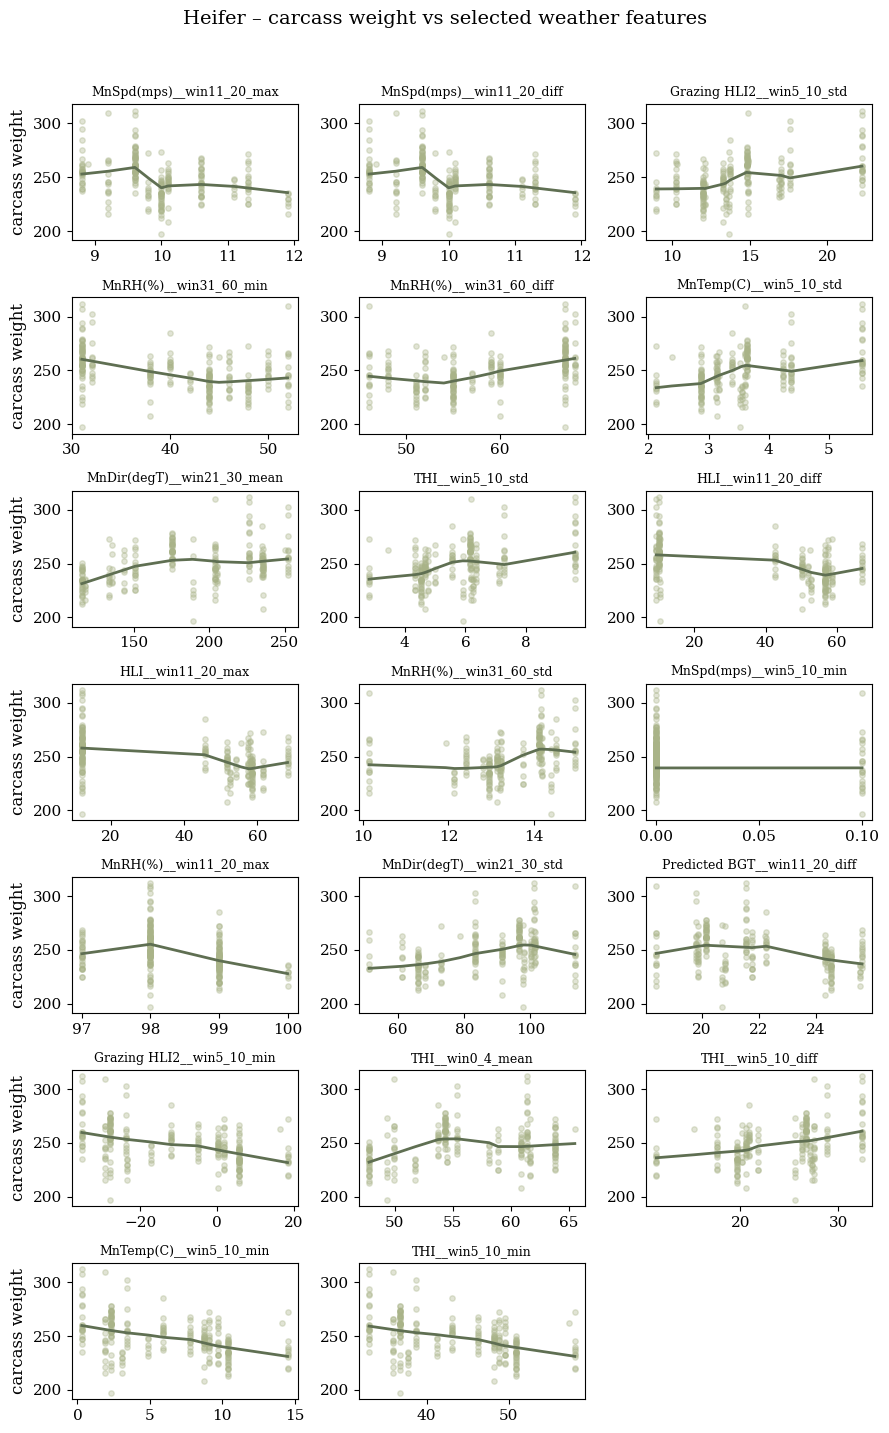

c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


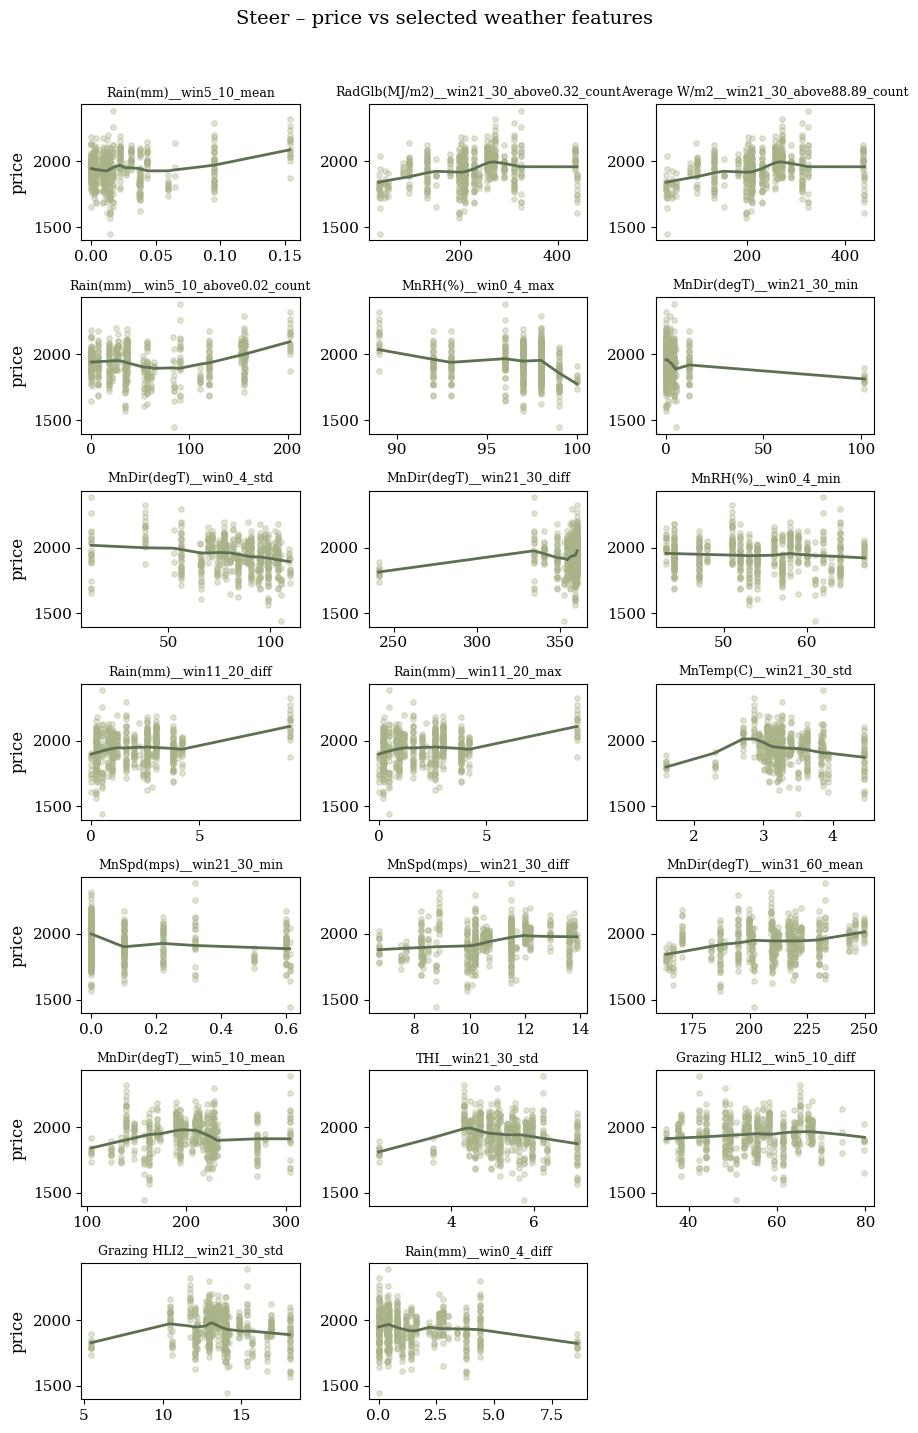

c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


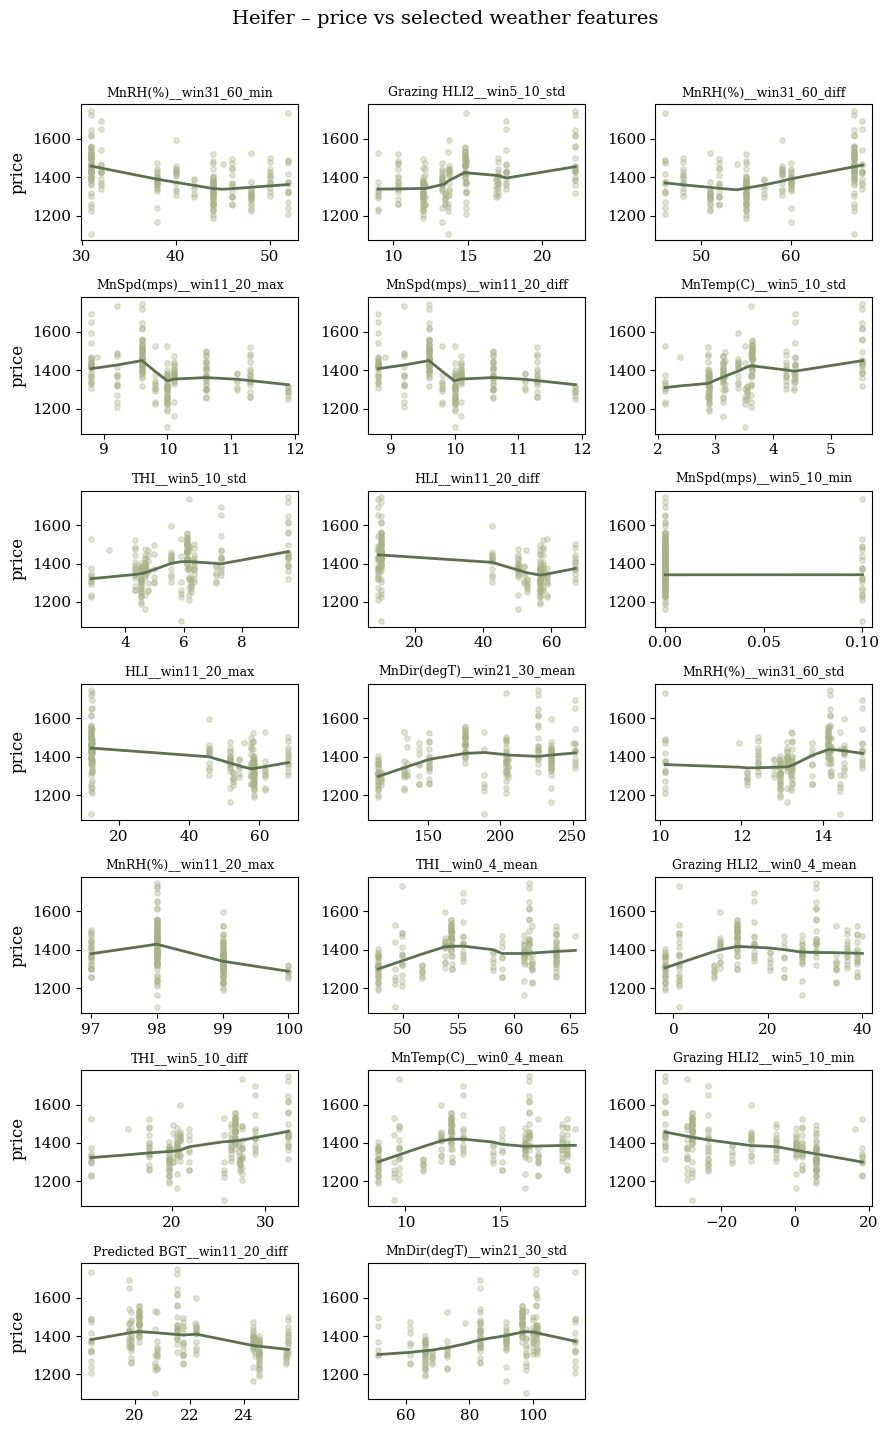

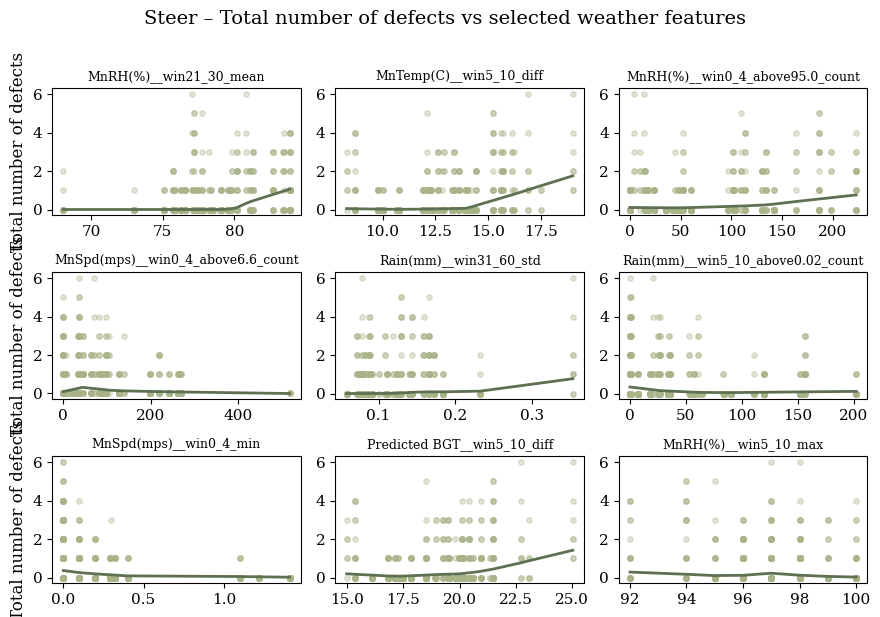

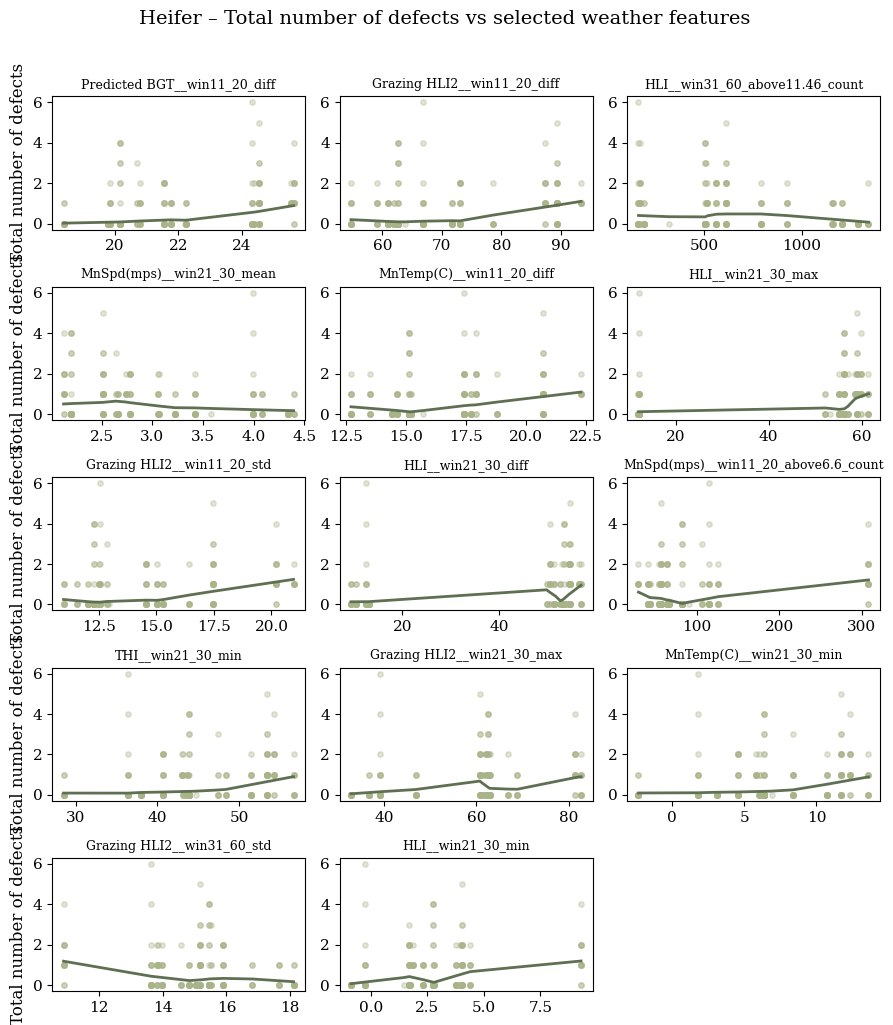

In [26]:
from math import ceil
from statsmodels.nonparametric.smoothers_lowess import lowess

def plot_feature_grid_for_target(df, selected_weather, target, atype,
                                 max_cols=3, frac=0.5):
    """
    Plot scatter + LOWESS for all selected weather features
    in a grid (one figure) for a given target & animal type.
    """
    feats = selected_weather.get((target, atype), [])
    if not feats:
        print(f"No selected weather features for {atype} / {target}")
        return

    sub = df[df["Animal Type"].str.lower() == atype].copy()
    # keep only relevant cols
    cols = feats + [target]
    sub = sub[cols].dropna()
    if sub.empty:
        print(f"No usable data for {atype} / {target} after dropna.")
        return

    n_feats = len(feats)
    ncols = min(max_cols, n_feats)
    nrows = ceil(n_feats / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3 * ncols, 2 * nrows),
        squeeze=False
    )

    for i, feat in enumerate(feats):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]

        x = sub[feat].values
        y = sub[target].values

        # LOWESS smoothing (smoother with higher frac)
        sm = lowess(y, x, frac=frac, return_sorted=True)
        x_smooth, y_smooth = sm[:, 0], sm[:, 1]

        # scatter
        ax.scatter(x, y, alpha=0.35, s=15, color=COLORS[1])
        # trend line
        ax.plot(x_smooth, y_smooth, color=COLORS[0], linewidth=2)

        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")   # keep clean; can add if you like
        ax.set_ylabel(target if c == 0 else "")

    # hide any unused axes
    for j in range(i + 1, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].set_visible(False)

    fig.suptitle(f"{atype.capitalize()} – {target} vs selected weather features",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ----- run for all targets & animal types -----
for target in targets:
    for atype in ["steer", "heifer"]:
        plot_feature_grid_for_target(
            df_all,
            selected_weather,
            target,
            atype,
            max_cols=3,   # 3 plots per row
            frac=0.6      # smoother trend lines
        )

# 2. Ablation study for all targets

Levels:

L1 – cow features only

L2 – cow features + selected important weather features

L3 – cow features + all weather features

We’ll use a single reasonably strong nonlinear model: LGBMRegressor, with 5-fold CV, per type & target.

### 2.1 Define “cow features” (non-weather, non-target, not in drop_features)

In [27]:
# reuse your drop_features list; remove 'Animal Type' since we subset by type
drop_features_no_type = [f for f in drop_features if f != "Animal Type"]

def get_cow_features(df):
    return [
        c for c in df.columns
        if c not in targets
        and c not in weather_features
        and c not in ['Animal Type_num', 'Animal Type']
        and c not in drop_features_no_type
    ]

print("Example cow features:", get_cow_features(df_all[df_all["Animal Type"].str.lower()=="steer"])[:10])

Example cow features: ['NZDI', 'Transport distance (calculated)', 'lairage time (calculated)']


### 2.2 Run ablation CV

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ablation_rows = []

for target in targets:
    for atype in ["steer", "heifer"]:
        sub = df_all[df_all["Animal Type"].str.lower() == atype].copy()

        cow_feats = get_cow_features(sub)

        # convenience function per level
        def run_level(level_name, feature_list):
            cols = feature_list + [target]
            tmp = sub[cols].dropna()

            X = tmp[feature_list]
            y = tmp[target]

            model = GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=100,
                max_depth=3
            )

            mae_scores = -cross_val_score(model, X, y, cv=cv,
                                          scoring="neg_mean_absolute_error")
            mse_scores  =  cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")

            ablation_rows.append({
                "animal_type": atype,
                "target": target,
                "level": level_name,
                "n_samples": len(y),
                "MAE_mean": mae_scores.mean(),
                "MAE_std": mae_scores.std(),
                "MSE_mean": mse_scores.mean(),
                "MSE_std": mse_scores.std(),
            })

        # Level 1: cow features only
        run_level("L1_cow_only", cow_feats)

        # Level 2: cow + ElasticNet-selected weather (if any)
        sel_feats = selected_weather.get((target, atype), [])
        if sel_feats:
            run_level("L2_cow_plus_selected_weather", cow_feats + sel_feats)

        # Level 3: cow + all weather
        run_level("L3_cow_plus_all_weather", cow_feats + weather_features)

ablation_results = pd.DataFrame(ablation_rows)
ablation_results


,animal_type,target,level,n_samples,MAE_mean,MAE_std,MSE_mean,MSE_std
0,steer,live weight,L1_cow_only,480,30.684763,3.369580,-2053.984809,1279.327870
1,steer,live weight,L2_cow_plus_selected_weather,453,30.502377,3.235981,-2076.002622,1483.750331
2,steer,live weight,L3_cow_plus_all_weather,453,30.504405,3.234087,-2075.992554,1483.457707
3,heifer,live weight,L1_cow_only,122,19.024693,1.677120,-694.307604,213.040851
4,heifer,live weight,L2_cow_plus_selected_weather,108,20.072745,4.616488,-774.382456,342.832900
5,heifer,live weight,L3_cow_plus_all_weather,108,20.072736,4.616488,-774.382284,342.832924
6,steer,carcass weight,L1_cow_only,480,15.428089,0.713264,-404.523122,42.108408
7,steer,carcass weight,L3_cow_plus_all_weather,453,15.504798,0.885704,-413.601704,33.116920
8,heifer,carcass weight,L1_cow_only,122,11.524015,1.627171,-251.178647,83.350022
9,heifer,carcass weight,L2_cow_plus_selected_weather,108,11.878013,2.131696,-271.703729,99.633251


### 2.3 Quick visual summary of ablation

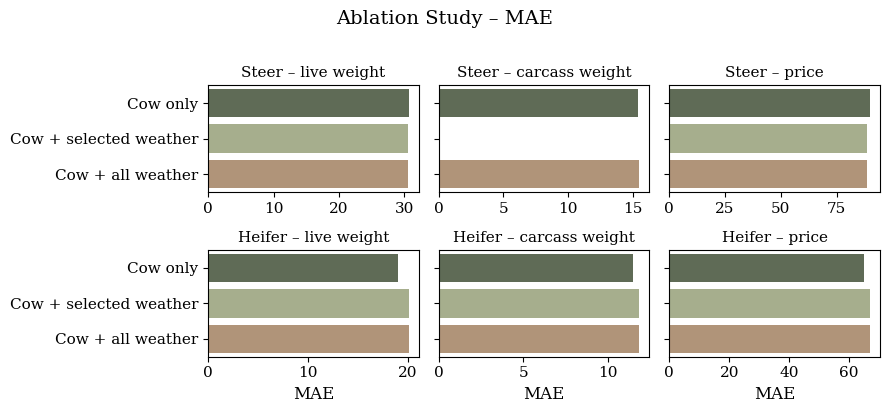

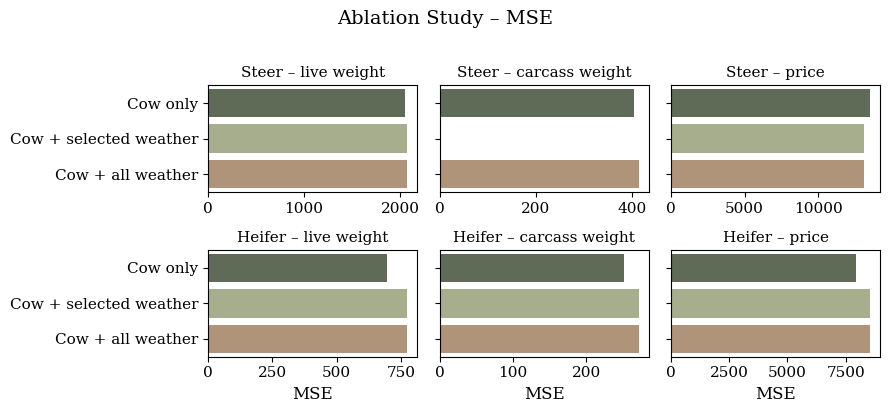

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

animal_types = ["steer", "heifer"]
target_list = targets[:3]

n_rows = len(animal_types)
n_cols = len(target_list)

# level order + nice labels
level_labels = {
    "L1_cow_only": "Cow only",
    "L2_cow_plus_selected_weather": "Cow + selected weather",
    "L3_cow_plus_all_weather": "Cow + all weather",
}
level_order = list(level_labels.keys())        # ['L1_cow_only', 'L2_cow_plus_selected_weather', ...]
nice_order  = list(level_labels.values())      # ['Cow only', 'Cow + selected weather', ...]
palette_nice = {nice: COLORS[i] for i, nice in enumerate(nice_order)}

metrics = [
    ("MAE_mean", "MAE"),
    ("MSE_mean", "MSE"),   # will be plotted as -MSE_mean
]

for metric_col, metric_label in metrics:

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3 * n_cols, 2 * n_rows),
        squeeze=False,
        sharey=True,
    )

    for i, atype in enumerate(animal_types):
        for j, target in enumerate(target_list):

            ax = axes[i, j]
            sub = ablation_results[
                (ablation_results["animal_type"] == atype) &
                (ablation_results["target"] == target)
            ].copy()

            if sub.empty:
                ax.set_visible(False)
                continue

            # keep only known levels and map to nice labels
            sub = sub[sub["level"].isin(level_order)].copy()
            if sub.empty:
                ax.set_visible(False)
                continue

            sub["level_nice"] = sub["level"].map(level_labels)

            # metric to plot
            if metric_label == "MSE":
                sub["_metric"] = -sub["MSE_mean"]   # higher = better
            else:
                sub["_metric"] = sub[metric_col]

            sns.barplot(
                data=sub,
                y="level_nice",
                x="_metric",
                hue="level_nice",
                order=nice_order,
                hue_order=nice_order,
                orient="h",
                palette=palette_nice,
                ax=ax,
                dodge=False,
            )

            # remove legends everywhere
            if ax.legend_:
                ax.legend_.remove()

            ax.set_title(f"{atype.capitalize()} – {target}", fontsize=11)

            # y-axis label only on leftmost column
            if j == 0:
                ax.set_ylabel("")  # labels are already the nice level names
            else:
                ax.set_ylabel("")

            # x-axis: only bottom row gets label
            if i == n_rows - 1:
                ax.set_xlabel(metric_label)
            else:
                ax.set_xlabel("")

    fig.suptitle(
        f"Ablation Study – {metric_label}",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


# Which windows are important for Life weight?

In [117]:
df_all = data[data["Animal Type"].str.lower().isin(["steer", "heifer", "cow"])].copy()

# identify weather features (all windows, incl. counts)
weather_features = [c for c in df_all.columns if "__win" in c]

# drop zero-variance weather cols
w_var = df_all[weather_features].var(numeric_only=True)
weather_features = [c for c in weather_features if w_var.get(c, 0) > 0]

In [118]:
from collections import defaultdict

# store selected weather features: (target, atype) -> list of feature names
selected_weather = defaultdict(list)

for target in ['live weight']: 
    for atype in ["steer", "heifer", "cow"]:
        sub = df_all[df_all["Animal Type"].str.lower() == atype].copy()

        cols = weather_features + [target]
        sub = sub[cols].dropna()

        X = sub[weather_features].copy()
        y = sub[target].copy()

        # drop remaining NaNs row-wise
        mask = ~X.isna().any(axis=1)
        X, y = X[mask], y[mask]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("enet", ElasticNetCV(
                cv=5,
                random_state=RANDOM_STATE,
                l1_ratio=[0.1, 0.5, 0.9, 1.0],
                max_iter=50000
            ))
        ])

        model.fit(X, y)

        coefs = pd.Series(model.named_steps["enet"].coef_, index=X.columns)
        nz = coefs[coefs != 0]

        if nz.empty:
            print(f"No non-zero weather coefs for {atype} / {target}.")
            continue

        # take top K by |coef|
        K = 20
        top = nz.reindex(nz.abs().sort_values(ascending=False).index[:K])
        selected_weather[(target, atype)] = top.index.tolist()

        print(f"{atype.upper()} / {target}: selected {len(top)} weather features.")


STEER / live weight: selected 20 weather features.
HEIFER / live weight: selected 6 weather features.
COW / live weight: selected 20 weather features.


c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


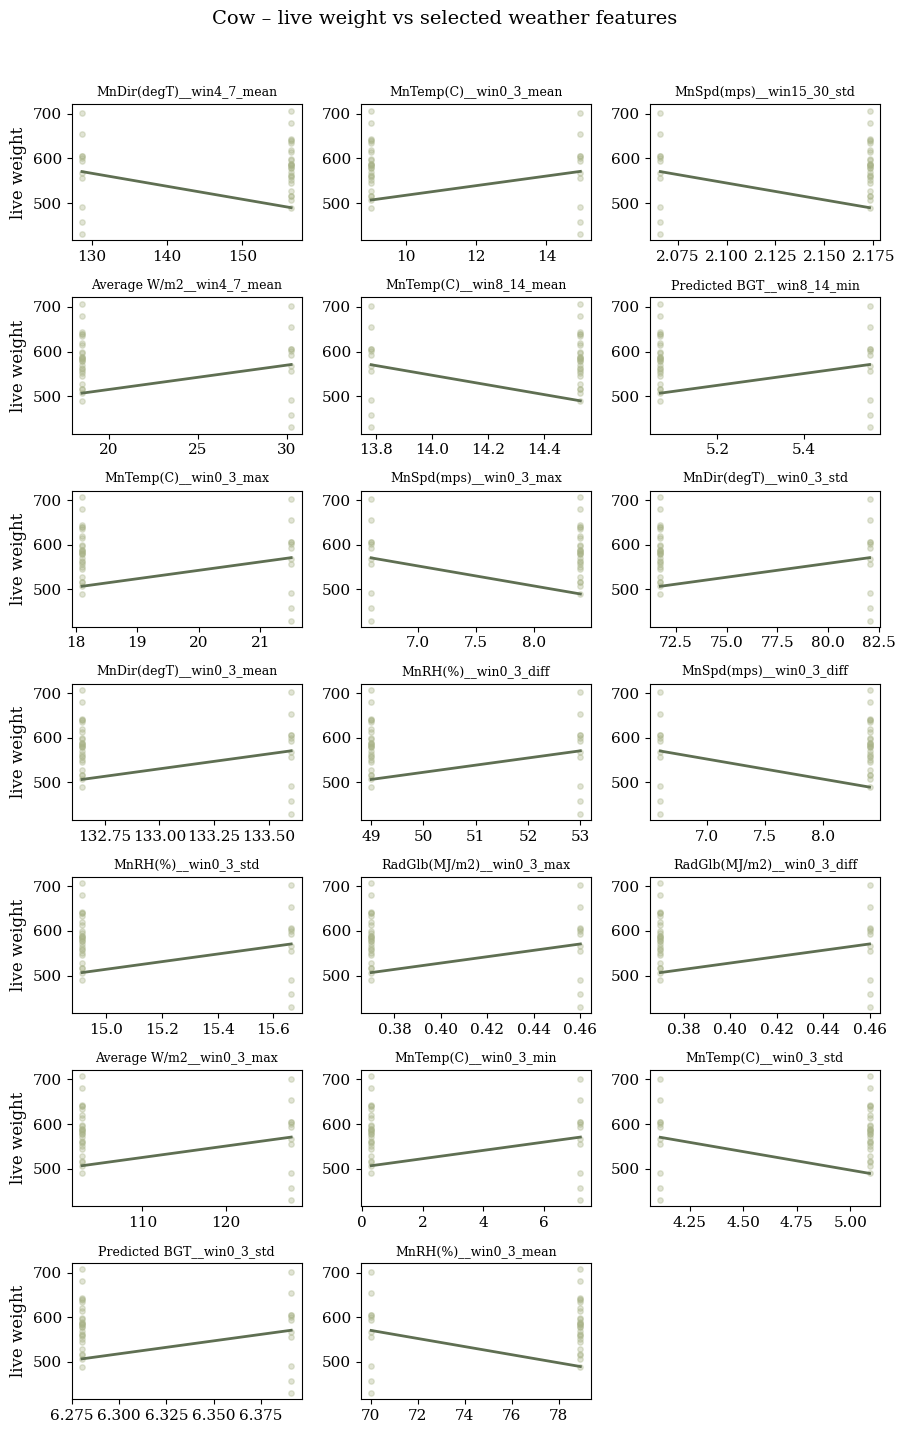

c:\Users\kdo88\Repos\Weather_vs_CowHealth\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


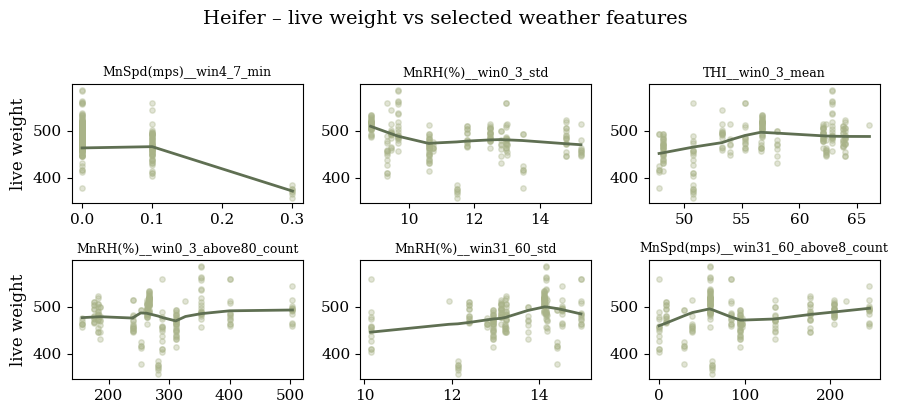

In [121]:
from math import ceil
from statsmodels.nonparametric.smoothers_lowess import lowess

def plot_feature_grid_for_target(df, selected_weather, target, atype,
                                 max_cols=3, frac=0.5):
    """
    Plot scatter + LOWESS for all selected weather features
    in a grid (one figure) for a given target & animal type.
    """
    feats = selected_weather.get((target, atype), [])
    if not feats:
        print(f"No selected weather features for {atype} / {target}")
        return

    sub = df[df["Animal Type"].str.lower() == atype].copy()
    # keep only relevant cols
    cols = feats + [target]
    sub = sub[cols].dropna()
    if sub.empty:
        print(f"No usable data for {atype} / {target} after dropna.")
        return

    n_feats = len(feats)
    ncols = min(max_cols, n_feats)
    nrows = ceil(n_feats / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3 * ncols, 2 * nrows),
        squeeze=False
    )

    for i, feat in enumerate(feats):
        r = i // ncols
        c = i % ncols
        ax = axes[r, c]

        x = sub[feat].values
        y = sub[target].values

        # LOWESS smoothing (smoother with higher frac)
        sm = lowess(y, x, frac=frac, return_sorted=True)
        x_smooth, y_smooth = sm[:, 0], sm[:, 1]

        # scatter
        ax.scatter(x, y, alpha=0.35, s=15, color=COLORS[1])
        # trend line
        ax.plot(x_smooth, y_smooth, color=COLORS[0], linewidth=2)

        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")   # keep clean; can add if you like
        ax.set_ylabel(target if c == 0 else "")

    # hide any unused axes
    for j in range(i + 1, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].set_visible(False)

    fig.suptitle(f"{atype.capitalize()} – {target} vs selected weather features",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ----- run for all targets & animal types -----
for target in ['live weight']:
    for atype in ["cow", "heifer"]:
        plot_feature_grid_for_target(
            df_all,
            selected_weather,
            target,
            atype,
            max_cols=3,   # 3 plots per row
            frac=0.6      # smoother trend lines
        )